In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zlib
import base64
import json
from genetic_instances import evalPatients, evaluate_local

In [3]:
file_names = ['summary_5_300_5_50.csv', 'summary_5_300_10_40.csv', 'summary_5_300_10_50.csv', 'summary_5_300_10_60.csv', 'summary_5_300_15_50.csv']
dfs = []
for p in file_names:
    print(p,':')
    df = pd.read_csv(f'out/{p}', index_col='Unnamed: 0')
    print("    before removing unsat", len(df))
    # filter out unsat instances
    df = df[df['optimal']!= -1]
    df['problem_str'] = df['problem']
    df['problem'] = df['problem'].apply(lambda x: json.loads(zlib.decompress(base64.b64decode(x.encode()))))
    # df = df[df['generation']<=50]
    
    assert (df['optimal']<=df['online']).all()
    print("    after removing unsat", len(df))
    print('    unique problems', len(set(df['problem_str'])))
    dfs.append(df)

summary_5_300_5_50.csv :
    before removing unsat 30000
    after removing unsat 30000
    unique problems 15790
summary_5_300_10_40.csv :
    before removing unsat 30000
    after removing unsat 29999
    unique problems 1737
summary_5_300_10_50.csv :
    before removing unsat 30000
    after removing unsat 30000
    unique problems 2499
summary_5_300_10_60.csv :
    before removing unsat 30000
    after removing unsat 30000
    unique problems 2002
summary_5_300_15_50.csv :
    before removing unsat 30000
    after removing unsat 29931
    unique problems 1778


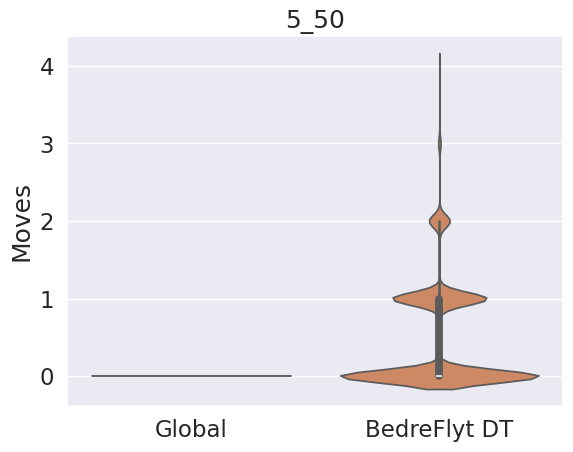

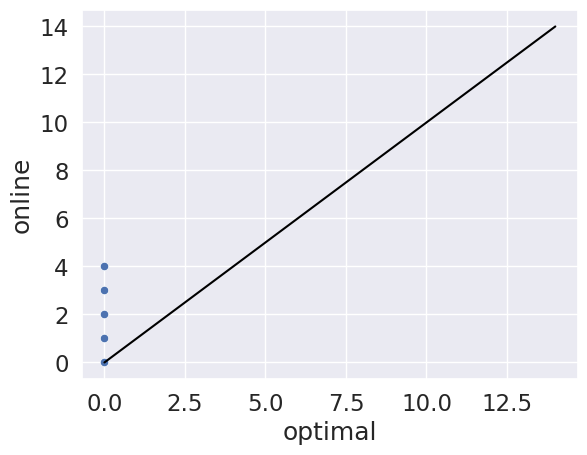

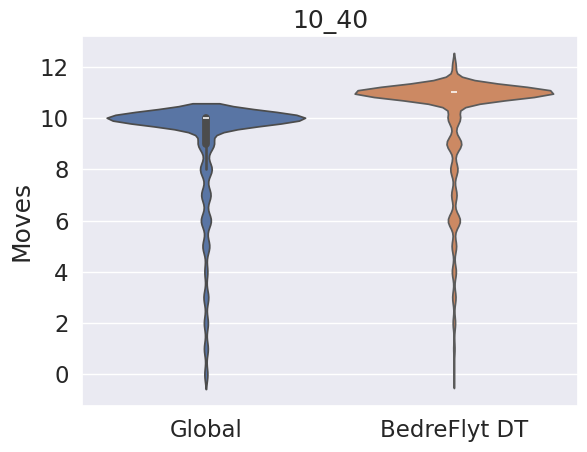

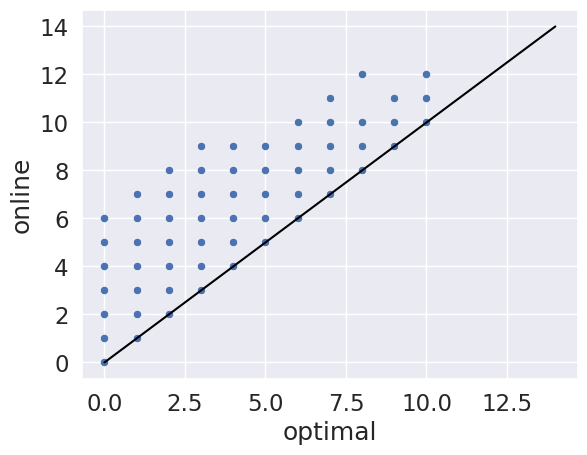

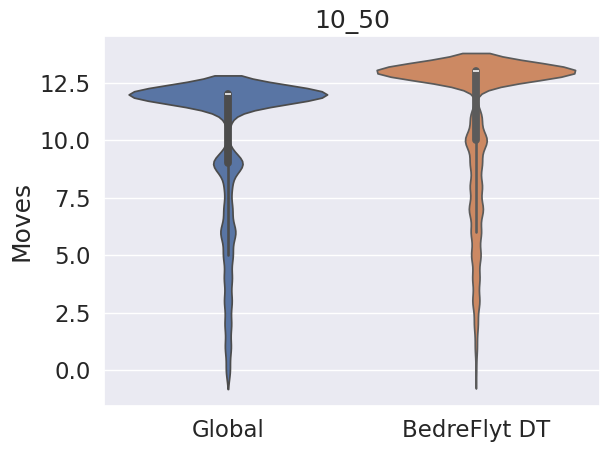

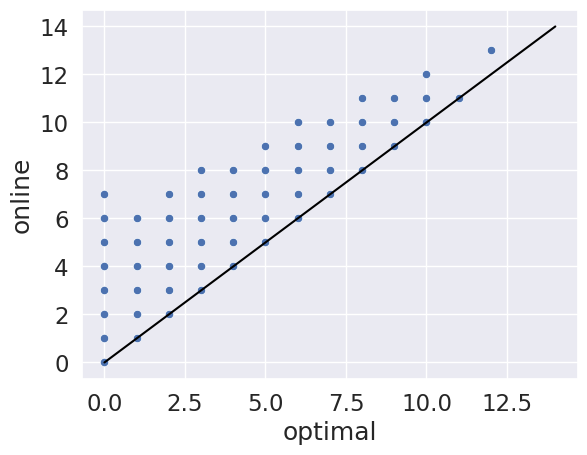

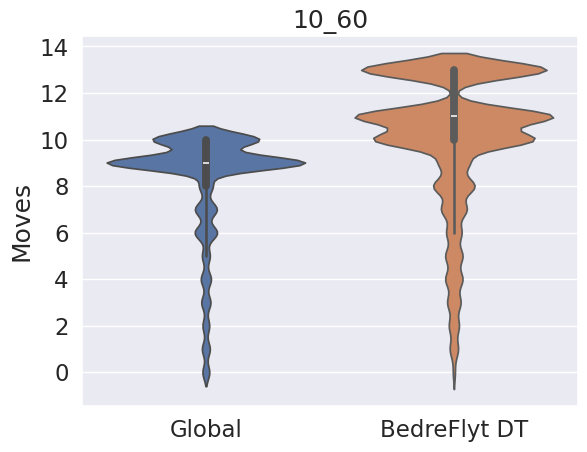

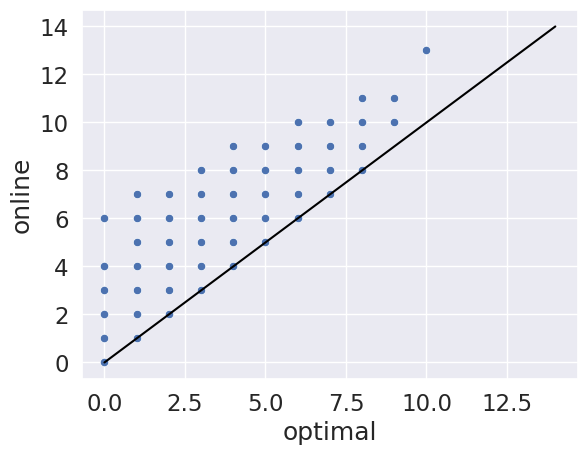

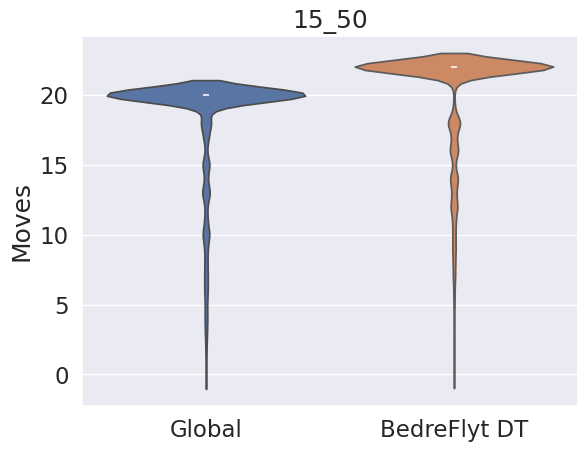

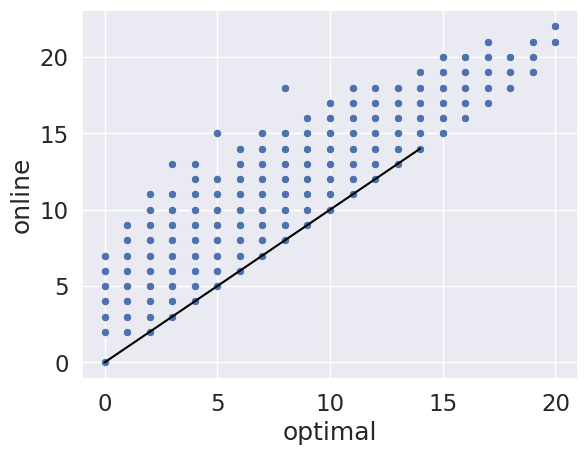

In [4]:
for df in dfs:
    sns.set_theme(font_scale = 1.5)
    sns.violinplot(df, y='optimal', x=['Global' for i in range(len(df))])
    sns.violinplot(df, y='online', x=['BedreFlyt DT' for i in range(len(df))])
    # plt.plot(df['optimal'], df['online'], c = "black")
    plt.ylabel("Moves")
    plt.savefig(f'out/patients_day{str(df["patients_day"].values[0])+"_patient_names"+str(df["patient_names"].values[0])}.png',bbox_inches='tight',dpi=300)
    plt.title(str(df['patients_day'].values[0])+"_"+str(df['patient_names'].values[0]))
    plt.show()
    sns.scatterplot(df, x='optimal', y='online')
    plt.plot([0,14], [0,14], c = "black")
    plt.show()

/tmp/ipykernel_17795/3392954812.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_0['fraction'] = df_no_0['online']/df_no_0['optimal']


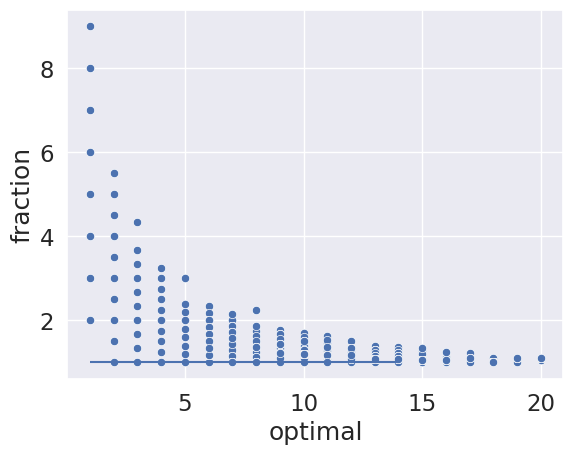

In [5]:
df_no_0 = df[df['optimal']!=0]
df_no_0['fraction'] = df_no_0['online']/df_no_0['optimal']
sns.scatterplot(df_no_0, x='optimal', y='fraction')
plt.hlines(y=[1], xmin=1, xmax=14)

In [6]:
# s = Solver()
# constraints = z3.parse_smt2_file('out/'+path, sorts={}, decls={})
# s.add(constraints)
# s.check()
# m = s.model()
# for var in m:
#     print(var)
# changes = [var for var in m if 'Number of changes' in str(var)]
# print(changes)
# assert(False)
# h = s.minimize(Sum([changes[p] for p in range()]))

from z3 import *
for path in ['1824']:
    s = Optimize()
    s.from_file('out/'+path)
    h = s.minimize(s.objectives()[0])
    print(s.check())
    m = s.model()
    s.lower(h) == s.upper(h)
    value = s.lower(h).as_long()
    print(value)
assert(False)

p = [{35: {'Cat': 1, 'Gender': False, 'Contagious': False}, 30: {'Cat': 1, 'Gender': False, 'Contagious': False}, 21: {'Cat': 2, 'Gender': True, 'Contagious': True}, 28: {'Cat': 2, 'Gender': False, 'Contagious': False}, 5: {'Cat': 3, 'Gender': False, 'Contagious': True}, 19: {'Cat': 1, 'Gender': True, 'Contagious': False}, 46: {'Cat': 2, 'Gender': False, 'Contagious': True}, 8: {'Cat': 2, 'Gender': True, 'Contagious': False}, 18: {'Cat': 3, 'Gender': False, 'Contagious': True}, 43: {'Cat': 3, 'Gender': False, 'Contagious': False}}, {44: {'Cat': 3, 'Gender': False, 'Contagious': True}, 47: {'Cat': 1, 'Gender': False, 'Contagious': True}, 37: {'Cat': 1, 'Gender': False, 'Contagious': False}, 43: {'Cat': 3, 'Gender': False, 'Contagious': True}, 4: {'Cat': 2, 'Gender': True, 'Contagious': False}, 18: {'Cat': 1, 'Gender': False, 'Contagious': True}, 25: {'Cat': 3, 'Gender': False, 'Contagious': False}, 6: {'Cat': 3, 'Gender': True, 'Contagious': False}, 9: {'Cat': 3, 'Gender': False, 'Contagious': True}, 31: {'Cat': 1, 'Gender': False, 'Contagious': False}}, {38: {'Cat': 3, 'Gender': True, 'Contagious': False}, 11: {'Cat': 3, 'Gender': False, 'Contagious': True}, 6: {'Cat': 2, 'Gender': False, 'Contagious': False}, 47: {'Cat': 3, 'Gender': True, 'Contagious': True}, 14: {'Cat': 3, 'Gender': True, 'Contagious': True}, 41: {'Cat': 2, 'Gender': True, 'Contagious': True}, 16: {'Cat': 3, 'Gender': True, 'Contagious': True}, 30: {'Cat': 3, 'Gender': True, 'Contagious': False}, 45: {'Cat': 1, 'Gender': False, 'Contagious': True}, 1: {'Cat': 1, 'Gender': False, 'Contagious': True}}, {28: {'Cat': 3, 'Gender': True, 'Contagious': True}, 49: {'Cat': 2, 'Gender': True, 'Contagious': False}, 34: {'Cat': 3, 'Gender': True, 'Contagious': True}, 45: {'Cat': 1, 'Gender': True, 'Contagious': False}, 9: {'Cat': 2, 'Gender': False, 'Contagious': True}, 30: {'Cat': 3, 'Gender': False, 'Contagious': False}, 29: {'Cat': 3, 'Gender': True, 'Contagious': True}, 10: {'Cat': 1, 'Gender': False, 'Contagious': False}, 48: {'Cat': 3, 'Gender': False, 'Contagious': True}, 47: {'Cat': 3, 'Gender': False, 'Contagious': False}}, {12: {'Cat': 3, 'Gender': False, 'Contagious': True}, 34: {'Cat': 1, 'Gender': False, 'Contagious': False}, 36: {'Cat': 3, 'Gender': True, 'Contagious': True}, 41: {'Cat': 3, 'Gender': True, 'Contagious': True}, 49: {'Cat': 3, 'Gender': False, 'Contagious': True}, 19: {'Cat': 2, 'Gender': True, 'Contagious': False}, 43: {'Cat': 2, 'Gender': True, 'Contagious': True}, 1: {'Cat': 1, 'Gender': False, 'Contagious': True}, 7: {'Cat': 3, 'Gender': True, 'Contagious': True}, 29: {'Cat': 2, 'Gender': False, 'Contagious': False}}]
global_results = evalPatients(p)
local_results = [evaluate_local(p)]
for i in range(10):
    global_results.append(evalPatients(p)[0])
    local_results.append(evaluate_local(p))
print("global", global_results)
print("local", local_results)
assert len(set(global_results)) == 1

Z3Exception: b'Could not open file out/1824'